Project paths ready
Figure Generation for Paper [Figure 6]: Comprehensive Quality Evaluation Results
Data loaded: data\agent3_ensemble_results_4industry.csv  (542 records)
  Pass:             133  (24.5%)
  Conditional Pass: 280  (51.7%)
  Reject:           129  (23.8%)
  Usability:        413  (76.2%)

[Figure 6] saved: results\figures\figure6_quality_evaluation_4industry.png


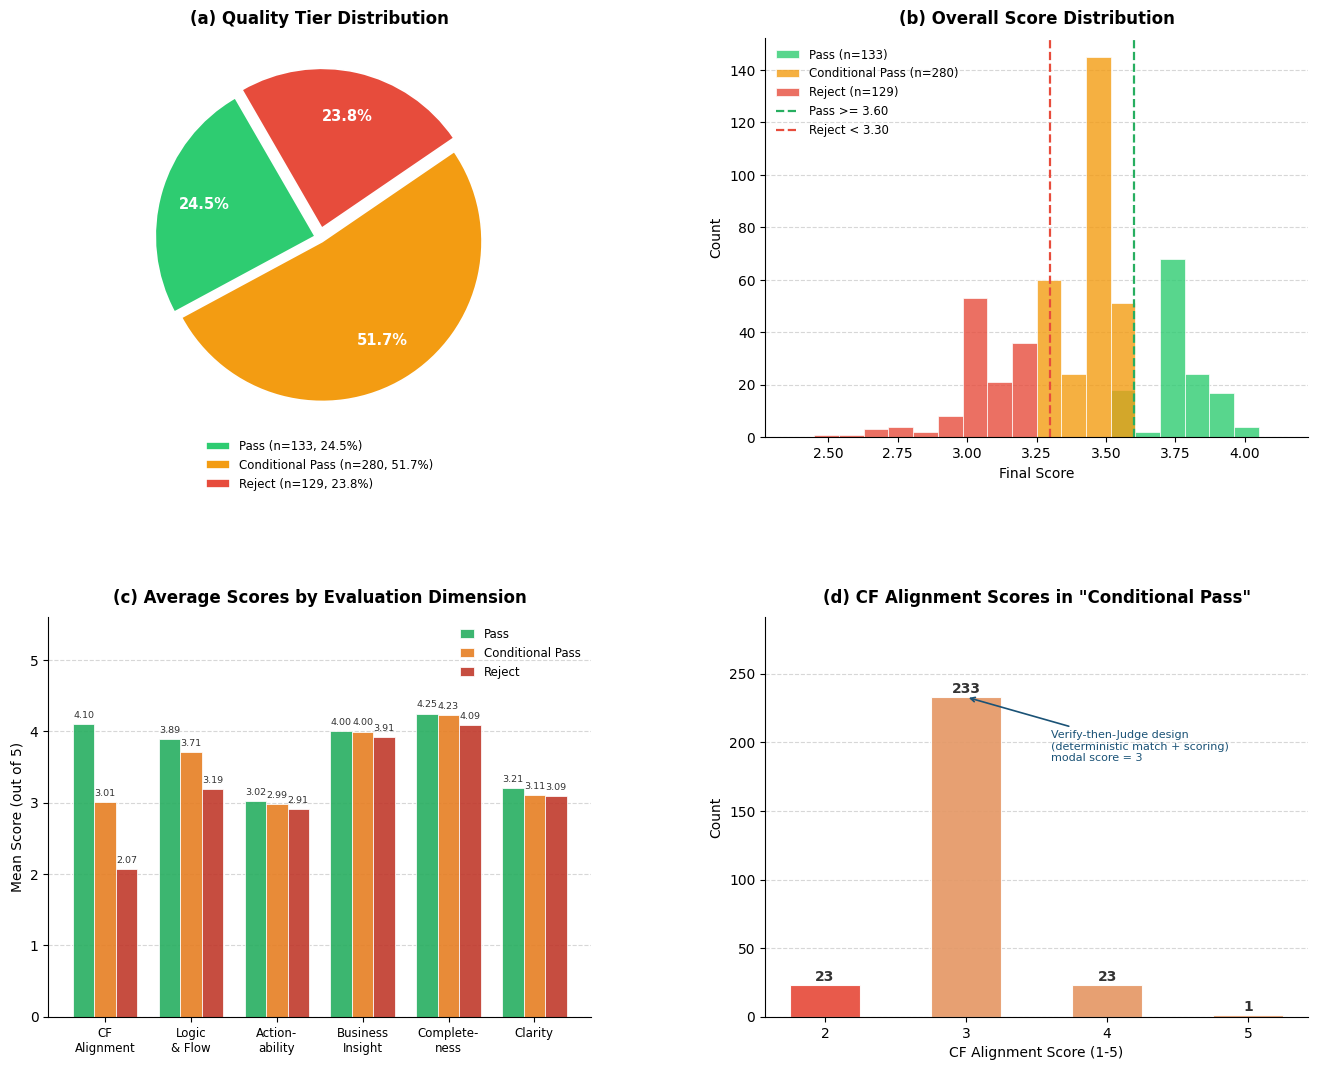


[Sanity Check] Mean scores by dimension and grade:
                  CF Alignment  Logic & Flow  Actionability  Business Insight  \
decision                                                                        
Pass                      4.10          3.89           3.02              4.00   
Conditional Pass          3.01          3.71           2.99              4.00   
Reject                    2.07          3.19           2.91              3.91   

                  Completeness  Clarity  
decision                                 
Pass                      4.25     3.21  
Conditional Pass          4.23     3.11  
Reject                    4.09     3.09  

[Sanity Check] Overall mean CF Alignment: 3.05 (paper baseline: ~2.0)


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# Project paths
# ============================================================================
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURE_DIR = RESULTS_DIR / 'figures'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths ready")

print("=" * 80)
print("Figure Generation for Paper [Figure 6]: Comprehensive Quality Evaluation Results")
print("=" * 80)

# ============================================================================
# 1. Load Data — real pipeline output ONLY. No synthetic/paper-value
#    fallback: if the file is missing or columns can't be resolved, this
#    must fail loudly rather than silently plot fabricated numbers as if
#    they were our results.
# ============================================================================
data_path = DATA_DIR / 'agent3_ensemble_results_4industry.csv'
if not data_path.exists():
    raise FileNotFoundError(
        f"{data_path} not found. Run Step 7 (Agent #3) first — "
        f"this figure must be generated from actual pipeline output, not paper-reported values."
    )

df = pd.read_csv(data_path)
print(f"Data loaded: {data_path.relative_to(PROJECT_ROOT)}  ({len(df)} records)")

# ============================================================================
# 2. Column Name Resolution — same resolver logic, but now raises instead
#    of silently degrading to a fallback if a dimension can't be found.
# ============================================================================
DIM_DISPLAY = ['CF Alignment', 'Logic & Flow', 'Actionability',
               'Business Insight', 'Completeness', 'Clarity']

DIM_CANDIDATES = {
    'CF Alignment':     ['score_cf_alignment'],
    'Logic & Flow':     ['score_logic_flow', 'score_logic_and_flow'],
    'Actionability':    ['score_actionability'],
    'Business Insight': ['score_business_insight'],
    'Completeness':     ['score_completeness'],
    'Clarity':          ['score_clarity'],
}

def resolve_col(df, dim):
    for cand in DIM_CANDIDATES[dim]:
        if cand in df.columns:
            return cand
    key = dim.lower().replace(' ', '_').replace('&', 'and').replace('/', '_')
    for col in df.columns:
        if key in col.lower():
            return col
    return None

SCORE_COLS = {d: resolve_col(df, d) for d in DIM_DISPLAY}
missing = [d for d, c in SCORE_COLS.items() if c is None]
if missing:
    raise ValueError(f"Could not resolve columns for dimensions: {missing}. "
                      f"Available columns: {list(df.columns)}")

if 'decision' not in df.columns:
    raise ValueError("'decision' column not found. Run Step 7 (Agent #3) first.")

# ============================================================================
# 3. Derived subsets — decision labels come directly from Step 7's own
#    threshold logic (>=3.60 Pass, >=3.30 Conditional Pass, else Reject),
#    NOT recomputed here via percentile. Recomputing via quantile would
#    silently redefine what "Pass" means, decoupled from the grading rule
#    actually applied when the reports were evaluated.
# ============================================================================
GRADE_ORDER = ['Pass', 'Conditional Pass', 'Reject']
df_pass = df[df['decision'] == 'Pass']
df_cond = df[df['decision'] == 'Conditional Pass']
df_reject = df[df['decision'] == 'Reject']
n_pass, n_cond, n_reject = len(df_pass), len(df_cond), len(df_reject)
total = len(df)

print(f"  Pass:             {n_pass}  ({n_pass/total*100:.1f}%)")
print(f"  Conditional Pass: {n_cond}  ({n_cond/total*100:.1f}%)")
print(f"  Reject:           {n_reject}  ({n_reject/total*100:.1f}%)")
print(f"  Usability:        {n_pass+n_cond}  ({(n_pass+n_cond)/total*100:.1f}%)")

# Actual thresholds used in Step 7 (agent3_ensemble_results generation),
# shown for reference on the histogram — these are the FIXED rule, not
# derived from this dataset's distribution.
STEP7_PASS_THRESHOLD = 3.60
STEP7_REJECT_THRESHOLD = 3.30

COLORS = {
    'Pass':             '#2ECC71',
    'Conditional Pass': '#F39C12',
    'Reject':           '#E74C3C',
}
COL_MAP = {
    'Pass':             '#27AE60',
    'Conditional Pass': '#E67E22',
    'Reject':           '#C0392B',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ============================================================================
# 4. Canvas — 2 x 2 grid
# ============================================================================
fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 2, figure=fig,
                       wspace=0.32, hspace=0.45,
                       left=0.07, right=0.97,
                       top=0.96,  bottom=0.07)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

SUBTITLE_KW = dict(fontsize=12, fontweight='bold', pad=10)

# ============================================================================
# (a) Grade Distribution — Pie
# ============================================================================
sizes = [n_pass, n_cond, n_reject]
colors = [COLORS['Pass'], COLORS['Conditional Pass'], COLORS['Reject']]
leg_labels = [
    f'Pass (n={n_pass}, {n_pass/total*100:.1f}%)',
    f'Conditional Pass (n={n_cond}, {n_cond/total*100:.1f}%)',
    f'Reject (n={n_reject}, {n_reject/total*100:.1f}%)',
]

wedges, _, autotexts = ax1.pie(
    sizes, colors=colors, explode=(0.03, 0.03, 0.06),
    autopct='%1.1f%%', startangle=120, pctdistance=0.72,
    wedgeprops=dict(linewidth=1.2, edgecolor='white'),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(10.5)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.legend(wedges, leg_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.16),
           fontsize=8.5, frameon=False)
ax1.set_title('(a) Quality Tier Distribution', **SUBTITLE_KW)

# ============================================================================
# (b) Overall Score Distribution — Histogram
#     Bin range now derived from the ACTUAL score range in this dataset,
#     not hardcoded to the paper's G46-only range (2.1-3.35). Our results
#     span a wider and generally higher range (mean 3.42).
# ============================================================================
score_min = df['final_score'].min()
score_max = df['final_score'].max()
bin_width = (score_max - score_min) / 18  # ~18 bins across the actual range
bins = np.arange(score_min - bin_width, score_max + bin_width * 2, bin_width)

for grade, grp, col in [
    ('Pass', df_pass, COLORS['Pass']),
    ('Conditional Pass', df_cond, COLORS['Conditional Pass']),
    ('Reject', df_reject, COLORS['Reject']),
]:
    ax2.hist(grp['final_score'], bins=bins, color=col,
             alpha=0.80, edgecolor='white', linewidth=0.6,
             label=f'{grade} (n={len(grp)})')

# Reference lines mark Step 7's ACTUAL fixed grading thresholds, not a
# distribution-derived percentile of this specific dataset.
ax2.axvline(STEP7_PASS_THRESHOLD, color='#27AE60', lw=1.6, ls='--',
            label=f'Pass >= {STEP7_PASS_THRESHOLD:.2f}')
ax2.axvline(STEP7_REJECT_THRESHOLD, color='#E74C3C', lw=1.6, ls='--',
            label=f'Reject < {STEP7_REJECT_THRESHOLD:.2f}')

ax2.set_xlabel('Final Score', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title('(b) Overall Score Distribution', **SUBTITLE_KW)
ax2.legend(fontsize=8.5, frameon=False, loc='upper left')
ax2.set_xlim(score_min - bin_width * 2, score_max + bin_width * 2)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# ============================================================================
# (c) Average Scores by Dimension — Grouped Bar
# ============================================================================
x = np.arange(len(DIM_DISPLAY))
width = 0.25
offsets = [-width, 0, width]

for grade, offset, col in zip(GRADE_ORDER, offsets, COL_MAP.values()):
    grp = df[df['decision'] == grade]
    means = []
    for d in DIM_DISPLAY:
        c = SCORE_COLS[d]
        val = grp[c].mean() if c in grp.columns else np.nan
        means.append(val)

    bars = ax3.bar(x + offset, means, width,
                   label=grade, color=col,
                   edgecolor='white', linewidth=0.6, alpha=0.90)

    for bar, val in zip(bars, means):
        if np.isfinite(val):
            ax3.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.06,
                     f'{val:.2f}',
                     ha='center', va='bottom',
                     fontsize=6.8, color='#333333')

short_labels = ['CF\nAlignment', 'Logic\n& Flow', 'Action-\nability',
                'Business\nInsight', 'Complete-\nness', 'Clarity']
ax3.set_xticks(x)
ax3.set_xticklabels(short_labels, fontsize=8.5)
ax3.set_ylabel('Mean Score (out of 5)', fontsize=10)
ax3.set_ylim(0, 5.6)
ax3.set_title('(c) Average Scores by Evaluation Dimension', **SUBTITLE_KW)
ax3.legend(fontsize=8.5, frameon=False, loc='upper right',
           ncol=1, handlelength=1.2)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5)
ax3.set_axisbelow(True)

# ============================================================================
# (d) CF Alignment in Conditional Pass — Bar
#     No synthetic fallback. Uses actual score_cf_alignment values from the
#     Conditional Pass subset of our real results.
# ============================================================================
cf_col = SCORE_COLS['CF Alignment']
cf_scores = df_cond[cf_col].dropna().round().astype(int)

if cf_scores.empty:
    raise ValueError("No Conditional Pass records with a valid CF Alignment score found.")

unique_scores = sorted(cf_scores.unique())
counts = [(cf_scores == s).sum() for s in unique_scores]

bar_colors = ['#E74C3C' if s <= 2 else '#E59866' for s in unique_scores]

bars = ax4.bar([str(s) for s in unique_scores], counts,
               color=bar_colors, edgecolor='white',
               linewidth=0.8, alpha=0.92, width=0.50)

for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.2,
             str(int(cnt)),
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#333333')

ax4.set_xlabel('CF Alignment Score (1-5)', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_title('(d) CF Alignment Scores in "Conditional Pass"', **SUBTITLE_KW)
ax4.set_ylim(0, max(counts) * 1.25)
ax4.yaxis.grid(True, linestyle='--', alpha=0.5)
ax4.set_axisbelow(True)

# Annotation now reflects the Verify-then-Judge redesign (Step 7), which
# improved mean CF Alignment from the paper's ~2.0 baseline to 3.05 overall
# in our pipeline. The dominant score bar is annotated with this context
# instead of the paper's "structural limitation" framing, which no longer
# describes our result set.
dom_idx = int(np.argmax(counts))
dominant_score = unique_scores[dom_idx]
ax4.annotate(
    f'Verify-then-Judge design\n(deterministic match + scoring)\nmodal score = {dominant_score}',
    xy=(dom_idx, counts[dom_idx]),
    xytext=(dom_idx + 0.6, counts[dom_idx] * 0.80),
    fontsize=8, color='#1A5276',
    arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.2),
    ha='left'
)

# ============================================================================
# 5. Save
# ============================================================================
out_path = FIGURE_DIR / 'figure6_quality_evaluation_4industry.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n[Figure 6] saved: {out_path.relative_to(PROJECT_ROOT)}")
plt.show()

# ============================================================================
# 6. Sanity summary printed alongside the figure
# ============================================================================
print("\n[Sanity Check] Mean scores by dimension and grade:")
summary_table = df.groupby('decision')[[SCORE_COLS[d] for d in DIM_DISPLAY]].mean().round(2)
summary_table.columns = DIM_DISPLAY
print(summary_table.reindex(GRADE_ORDER))

print(f"\n[Sanity Check] Overall mean CF Alignment: {df[SCORE_COLS['CF Alignment']].mean():.2f} "
      f"(paper baseline: ~2.0)")